In [1]:
!pip install torch torchvision
!pip install git+https://github.com/openai/CLIP.git
!pip install matplotlib tqdm

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-cuen9i0g
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-cuen9i0g
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=da11d15b9fea12cfaf7f927ce410b702c0f130064f867b0d0d12b2b40cf17cd2
  Stored in directory: /tmp/pip-ephem-wheel-cache-6dqod3fc/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [2]:
import torch
import clip
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 105MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [7]:
dataset = STL10(root="./data", split="test", download=True)

classes = dataset.classes
texts = [f"a photo of a {c}" for c in classes]

text_tokens = clip.tokenize(texts).to(device)

with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)

### Image–Text Matching

=== Image-Text Matching ===


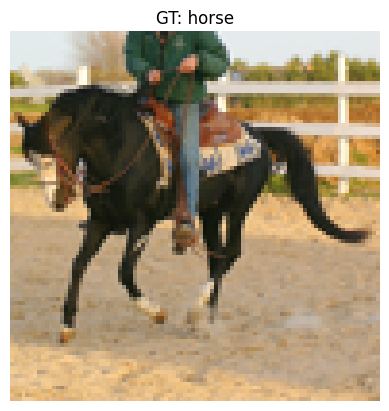


Similarity scores:
a photo of a airplane    : 0.0968
a photo of a bird        : 0.0997
a photo of a car         : 0.0988
a photo of a cat         : 0.1005
a photo of a deer        : 0.0994
a photo of a dog         : 0.1009
a photo of a horse       : 0.1070
a photo of a monkey      : 0.1002
a photo of a ship        : 0.0974
a photo of a truck       : 0.0994

Prediction: horse


In [8]:
print("=== Image-Text Matching ===")

image, label = dataset[0]

plt.imshow(image)
plt.title(f"GT: {classes[label]}")
plt.axis("off")
plt.show()

image_input = preprocess(image).unsqueeze(0).to(device)

with torch.no_grad():
    image_features = model.encode_image(image_input)
    image_features /= image_features.norm(dim=-1, keepdim=True)

    similarity = (image_features @ text_features.T).squeeze(0)
    probs = similarity.softmax(dim=0)

print("\nSimilarity scores:")
for t, p in zip(texts, probs):
    print(f"{t:25s}: {p.item():.4f}")

pred = similarity.argmax().item()
print("\nPrediction:", classes[pred])

### Zero-shot Classification


=== Zero-shot Classification (Debug + Show Image) ===


  0%|          | 0/10 [00:00<?, ?it/s]

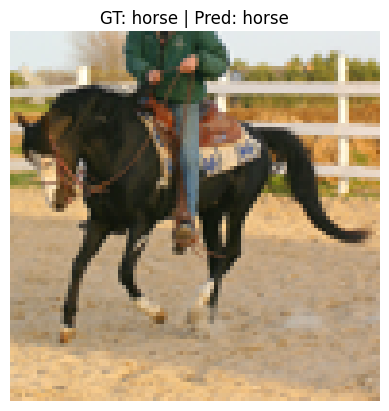


Sample 0
Ground Truth: horse

Image embedding (first 10 dims):
[-0.004368  0.02219   0.003094  0.01694   0.05008  -0.05594   0.01029
 -0.0289    0.011955  0.00955 ]

Similarity scores:
airplane       : 0.1558
bird           : 0.1846
car            : 0.1758
cat            : 0.1926
deer           : 0.1821
dog            : 0.1967
horse          : 0.2554
monkey         : 0.1898
ship           : 0.1616
truck          : 0.1825

Probabilities:
airplane       : 0.0968
bird           : 0.0997
car            : 0.0988
cat            : 0.1005
deer           : 0.0994
dog            : 0.1009
horse          : 0.1070
monkey         : 0.1002
ship           : 0.0974
truck          : 0.0994

Prediction vs Ground Truth:
GT   : horse
Pred : horse
Correct


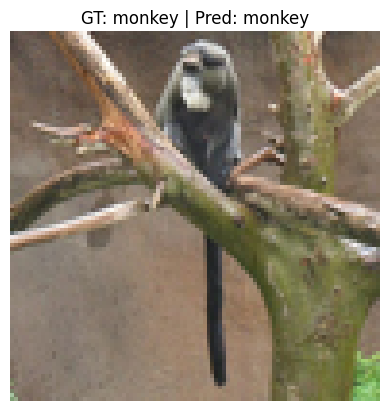

 20%|██        | 2/10 [00:00<00:00, 14.55it/s]


Sample 1
Ground Truth: monkey

Image embedding (first 10 dims):
[-8.430e-03  2.713e-02 -8.112e-05 -2.313e-02  3.223e-03 -1.689e-02
  1.174e-02 -2.701e-03  2.570e-02  4.587e-02]

Similarity scores:
airplane       : 0.1755
bird           : 0.2620
car            : 0.1974
cat            : 0.2318
deer           : 0.2041
dog            : 0.2286
horse          : 0.2213
monkey         : 0.3069
ship           : 0.1981
truck          : 0.1971

Probabilities:
airplane       : 0.0954
bird           : 0.1040
car            : 0.0975
cat            : 0.1009
deer           : 0.0981
dog            : 0.1006
horse          : 0.0999
monkey         : 0.1088
ship           : 0.0975
truck          : 0.0975

Prediction vs Ground Truth:
GT   : monkey
Pred : monkey
Correct


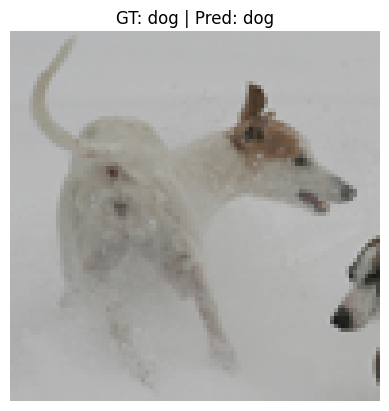


Sample 2
Ground Truth: dog

Image embedding (first 10 dims):
[-0.013466  -0.000884  -0.00327    0.0651     0.000712  -0.04477
  0.05432    0.0005484  0.03047    0.0006127]

Similarity scores:
airplane       : 0.1697
bird           : 0.1814
car            : 0.1881
cat            : 0.1978
deer           : 0.2128
dog            : 0.2561
horse          : 0.2095
monkey         : 0.1887
ship           : 0.1744
truck          : 0.1898

Probabilities:
airplane       : 0.0973
bird           : 0.0984
car            : 0.0991
cat            : 0.1000
deer           : 0.1016
dog            : 0.1061
horse          : 0.1013
monkey         : 0.0992
ship           : 0.0978
truck          : 0.0992

Prediction vs Ground Truth:
GT   : dog
Pred : dog
Correct


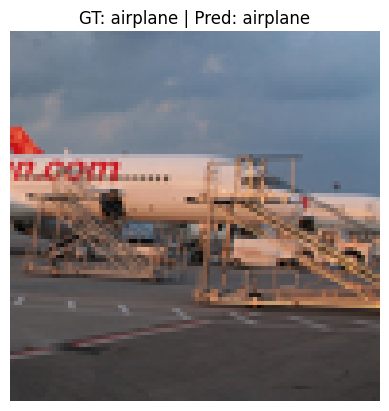

 40%|████      | 4/10 [00:00<00:00, 14.87it/s]


Sample 3
Ground Truth: airplane

Image embedding (first 10 dims):
[ 0.00796   0.006298 -0.02701   0.07135   0.04654  -0.01987   0.02306
 -0.01619  -0.01624   0.0426  ]

Similarity scores:
airplane       : 0.2391
bird           : 0.1876
car            : 0.1920
cat            : 0.1741
deer           : 0.1608
dog            : 0.1758
horse          : 0.1735
monkey         : 0.1860
ship           : 0.1971
truck          : 0.1774

Probabilities:
airplane       : 0.1054
bird           : 0.1001
car            : 0.1005
cat            : 0.0988
deer           : 0.0975
dog            : 0.0989
horse          : 0.0987
monkey         : 0.1000
ship           : 0.1011
truck          : 0.0991

Prediction vs Ground Truth:
GT   : airplane
Pred : airplane
Correct


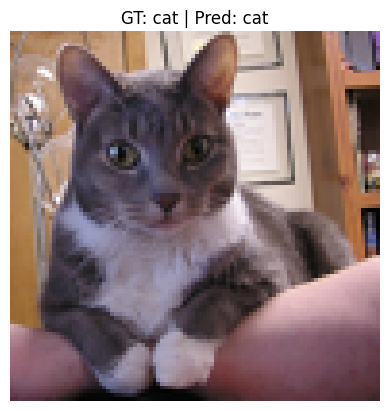


Sample 4
Ground Truth: cat

Image embedding (first 10 dims):
[-0.0282    -0.00243   -0.00863    0.01454    0.000933  -0.0001154
  0.01132    0.008766   0.01724   -0.01772  ]

Similarity scores:
airplane       : 0.1697
bird           : 0.2010
car            : 0.1819
cat            : 0.2649
deer           : 0.1844
dog            : 0.2200
horse          : 0.1969
monkey         : 0.2078
ship           : 0.1906
truck          : 0.1910

Probabilities:
airplane       : 0.0969
bird           : 0.1000
car            : 0.0981
cat            : 0.1066
deer           : 0.0983
dog            : 0.1019
horse          : 0.0995
monkey         : 0.1006
ship           : 0.0989
truck          : 0.0990

Prediction vs Ground Truth:
GT   : cat
Pred : cat
Correct


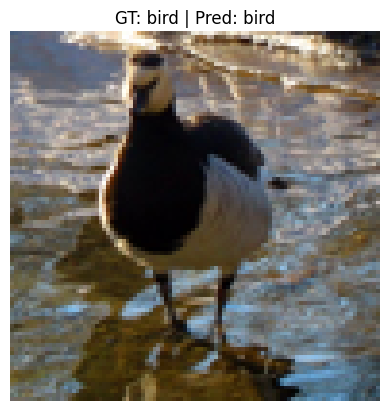


Sample 5
Ground Truth: bird

Image embedding (first 10 dims):
[ 0.03833   0.02963   0.01414   0.00599   0.02428  -0.02803   0.04074
  0.013405  0.0568    0.03137 ]

Similarity scores:


 60%|██████    | 6/10 [00:00<00:00, 14.95it/s]

airplane       : 0.1825
bird           : 0.2842
car            : 0.1874
cat            : 0.2135
deer           : 0.2234
dog            : 0.2321
horse          : 0.2246
monkey         : 0.2079
ship           : 0.1929
truck          : 0.1952

Probabilities:
airplane       : 0.0968
bird           : 0.1072
car            : 0.0973
cat            : 0.0999
deer           : 0.1009
dog            : 0.1017
horse          : 0.1010
monkey         : 0.0993
ship           : 0.0978
truck          : 0.0981

Prediction vs Ground Truth:
GT   : bird
Pred : bird
Correct


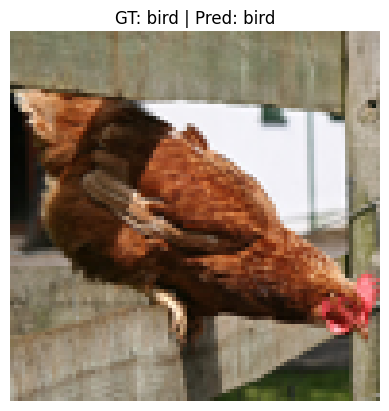


Sample 6
Ground Truth: bird

Image embedding (first 10 dims):
[ 0.03128  -0.00247   0.0098    0.00637   0.004047 -0.01642   0.03784
  0.0212    0.01352   0.03812 ]

Similarity scores:
airplane       : 0.1659
bird           : 0.2460
car            : 0.1873
cat            : 0.2028
deer           : 0.1764
dog            : 0.2126
horse          : 0.2150
monkey         : 0.1827
ship           : 0.1805
truck          : 0.2003

Probabilities:
airplane       : 0.0969
bird           : 0.1050
car            : 0.0990
cat            : 0.1006
deer           : 0.0980
dog            : 0.1016
horse          : 0.1018
monkey         : 0.0986
ship           : 0.0983
truck          : 0.1003

Prediction vs Ground Truth:
GT   : bird
Pred : bird
Correct


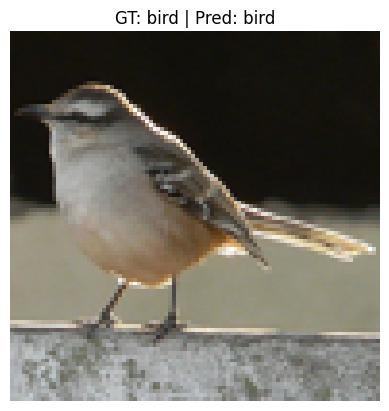


Sample 7
Ground Truth: bird

Image embedding (first 10 dims):
[ 0.01874    0.0489    -0.03052   -0.0336    -0.010895   0.03345
  0.04544   -0.0006094 -0.009865   0.01717  ]

Similarity scores:


 80%|████████  | 8/10 [00:00<00:00, 14.85it/s]

airplane       : 0.1855
bird           : 0.2922
car            : 0.1901
cat            : 0.2103
deer           : 0.1898
dog            : 0.2120
horse          : 0.1873
monkey         : 0.1932
ship           : 0.1982
truck          : 0.1949

Probabilities:
airplane       : 0.0980
bird           : 0.1090
car            : 0.0984
cat            : 0.1005
deer           : 0.0984
dog            : 0.1006
horse          : 0.0981
monkey         : 0.0988
ship           : 0.0992
truck          : 0.0989

Prediction vs Ground Truth:
GT   : bird
Pred : bird
Correct


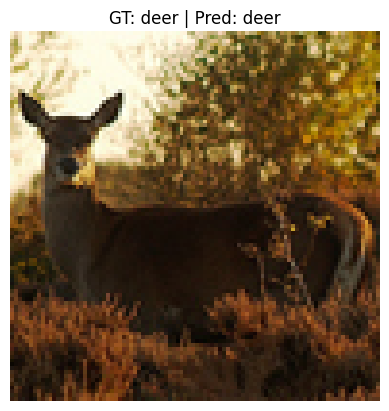


Sample 8
Ground Truth: deer

Image embedding (first 10 dims):
[-0.02718   0.010445 -0.01312  -0.00727   0.001495  0.01169   0.02078
 -0.008354  0.04376   0.02357 ]

Similarity scores:
airplane       : 0.1689
bird           : 0.2212
car            : 0.1951
cat            : 0.2098
deer           : 0.2903
dog            : 0.2292
horse          : 0.2268
monkey         : 0.2106
ship           : 0.1866
truck          : 0.1936

Probabilities:
airplane       : 0.0956
bird           : 0.1008
car            : 0.0981
cat            : 0.0996
deer           : 0.1080
dog            : 0.1016
horse          : 0.1013
monkey         : 0.0997
ship           : 0.0974
truck          : 0.0980

Prediction vs Ground Truth:
GT   : deer
Pred : deer
Correct


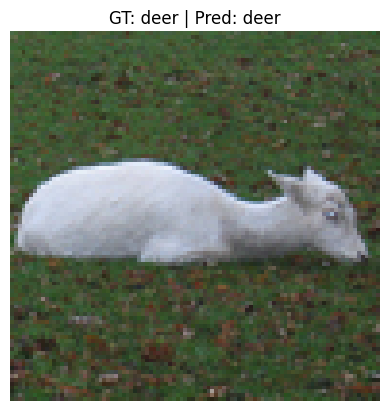

100%|██████████| 10/10 [00:00<00:00, 14.88it/s]


Sample 9
Ground Truth: deer

Image embedding (first 10 dims):
[ 0.00465   0.00027  -0.003296  0.05103   0.01773  -0.01162   0.01947
 -0.003742  0.002356  0.0195  ]

Similarity scores:
airplane       : 0.1959
bird           : 0.2260
car            : 0.2095
cat            : 0.2363
deer           : 0.2712
dog            : 0.2520
horse          : 0.2546
monkey         : 0.2126
ship           : 0.1998
truck          : 0.2018

Probabilities:
airplane       : 0.0970
bird           : 0.1000
car            : 0.0983
cat            : 0.1010
deer           : 0.1046
dog            : 0.1026
horse          : 0.1029
monkey         : 0.0986
ship           : 0.0974
truck          : 0.0976

Prediction vs Ground Truth:
GT   : deer
Pred : deer
Correct

Final Accuracy: 1.0


In [14]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

print("\n=== Zero-shot Classification (Debug + Show Image) ===")

correct = 0
total = 10

for i in tqdm(range(total)):
    image, label = dataset[i]
    image_input = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        # ===== ENCODE =====
        image_features = model.encode_image(image_input)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        similarity = (image_features @ text_features.T).squeeze(0)
        probs = similarity.softmax(dim=0)

    pred = similarity.argmax().item()

    # ===== SHOW IMAGE =====
    plt.imshow(image)
    plt.title(f"GT: {dataset.classes[label]} | Pred: {dataset.classes[pred]}")
    plt.axis("off")
    plt.show()

    # ===== PRINT INFO =====
    print("\n" + "="*60)
    print(f"Sample {i}")
    print("Ground Truth:", dataset.classes[label])

    # embedding (rút gọn)
    print("\nImage embedding (first 10 dims):")
    print(image_features[0][:10].cpu().numpy())

    # similarity
    print("\nSimilarity scores:")
    for cls, score in zip(dataset.classes, similarity):
        print(f"{cls:15s}: {score.item():.4f}")

    # probability
    print("\nProbabilities:")
    for cls, p in zip(dataset.classes, probs):
        print(f"{cls:15s}: {p.item():.4f}")

    # prediction
    print("\nPrediction vs Ground Truth:")
    print("GT   :", dataset.classes[label])
    print("Pred :", dataset.classes[pred])

    if pred == label:
        print("Correct")
        correct += 1
    else:
        print("Wrong")

# ===== FINAL =====
print("\n" + "="*60)
print("Final Accuracy:", correct / total)

### Image Retrieval (Text → Image)


=== Image Retrieval ===


100%|██████████| 300/300 [00:03<00:00, 96.71it/s] 


Top-5 indices: tensor([213,  23, 205, 129,  21], device='cuda:0')


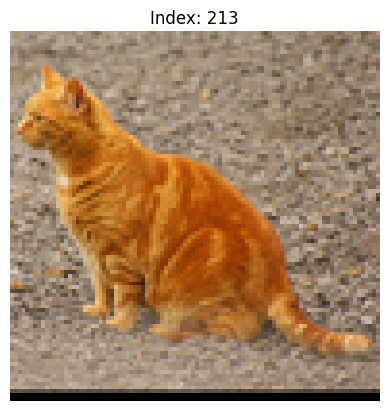

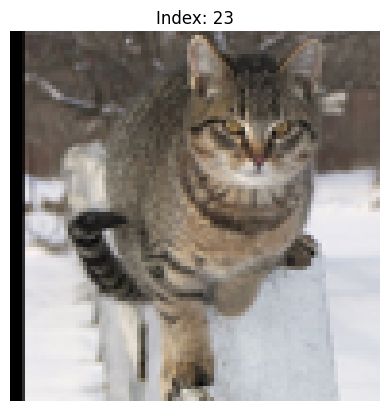

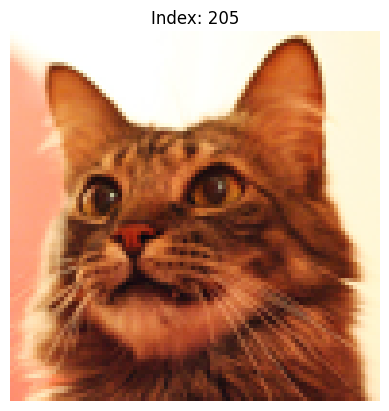

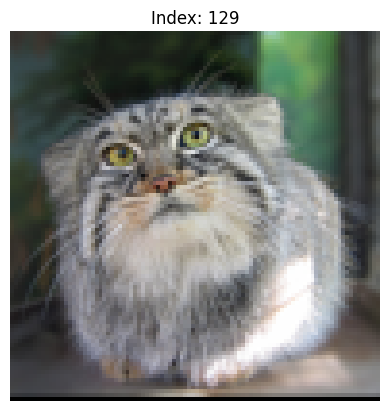

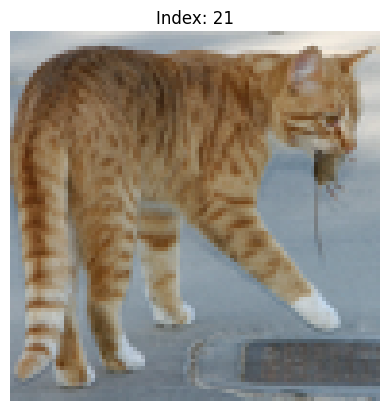

In [16]:
print("\n=== Image Retrieval ===")

# encode images
image_features_list = []

subset_size = 300

for i in tqdm(range(subset_size)):
    img, _ = dataset[i]
    img_input = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        feat = model.encode_image(img_input)
        feat /= feat.norm(dim=-1, keepdim=True)
        image_features_list.append(feat)

image_features = torch.cat(image_features_list)

# query
# query = "a photo of a cat"
query = "a photo of a dog"
text = clip.tokenize([query]).to(device)

with torch.no_grad():
    text_feature = model.encode_text(text)
    text_feature /= text_feature.norm(dim=-1, keepdim=True)

similarity = (text_feature @ image_features.T).squeeze(0)
topk = similarity.topk(5)

print("Top-5 indices:", topk.indices)

# visualize
for idx in topk.indices:
    img, _ = dataset[idx]
    plt.imshow(img)
    plt.title(f"Index: {idx}")
    plt.axis("off")
    plt.show()

### Text Retrieval (Image → Text)


=== Text Retrieval ===


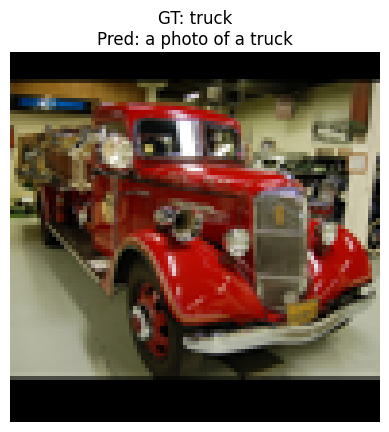

Best caption: a photo of a truck

Top-3 captions:
a photo of a truck  (0.2201)
a photo of a car  (0.2123)
a photo of a ship  (0.1740)


In [21]:
import matplotlib.pyplot as plt

print("\n=== Text Retrieval ===")

image, label = dataset[17]
image_input = preprocess(image).unsqueeze(0).to(device)

candidate_texts = texts
text_tokens = clip.tokenize(candidate_texts).to(device)

with torch.no_grad():
    image_feature = model.encode_image(image_input)
    text_features = model.encode_text(text_tokens)

    image_feature /= image_feature.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

similarity = (image_feature @ text_features.T).squeeze(0)

# ===== Prediction =====
best_idx = similarity.argmax().item()

# ===== Top-k =====
topk = similarity.topk(3)

# ===== SHOW IMAGE =====
plt.imshow(image)
plt.title(
    f"GT: {dataset.classes[label]}\n"
    f"Pred: {candidate_texts[best_idx]}"
)
plt.axis("off")
plt.show()

# ===== PRINT TEXT =====
print("Best caption:", candidate_texts[best_idx])

print("\nTop-3 captions:")
for idx in topk.indices:
    print(f"{candidate_texts[idx]}  ({similarity[idx].item():.4f})")